# k-means 알고리즘으로 붓꽃 품종 구분하기

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
KM = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
KM.fit(iris_df)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [5]:
KM.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [8]:
iris_df['target'] = iris.target   # 실제값
iris_df['cluster'] = KM.labels_
iris_df.groupby(['target', 'cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

# 실루엣(silhouette) 계수 측정

In [11]:
from sklearn.metrics import silhouette_score, silhouette_samples
score_samples = silhouette_samples(iris.data, iris_df['cluster'])
iris_df['silhouette_coeff'] = score_samples
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [12]:
silhouette_score(iris.data, iris_df['cluster'])

np.float64(0.5511916046195919)

# 실루엣 차트

In [13]:
import matplotlib.pyplot as plt

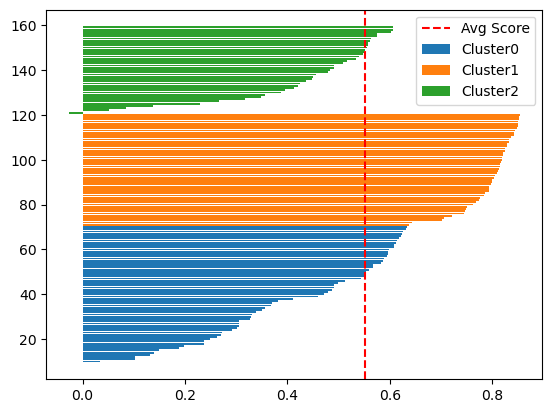

In [18]:
y_lower = 10
for i in range(3):
    cluster_i = score_samples[iris_df['cluster']==i]
    cluster_i.sort()
    y_upper = y_lower + len(cluster_i)
    plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
    y_lower = y_upper
    
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label='Avg Score')
plt.legend()
plt.show()

# scree plot (엘보우 기법)

In [19]:
KM.inertia_

78.85566582597728

In [21]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

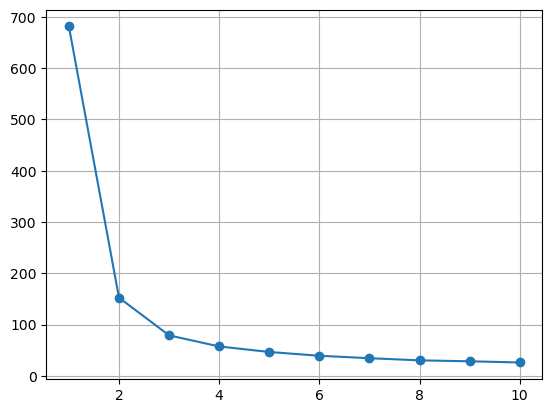

In [26]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(scree_df)
    inertia.append(kmeans.inertia_)
    
plt.plot(k_values, inertia, marker='o')
plt.grid()
plt.show()

# PCA > 2개의 주성분으로 축소

In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)
pca_transformed.shape

(150, 2)

In [55]:
iris_df['pca_x'] = pca_transformed[:, 0]
iris_df['pca_y'] = pca_transformed[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


# PCA 결과 시각화

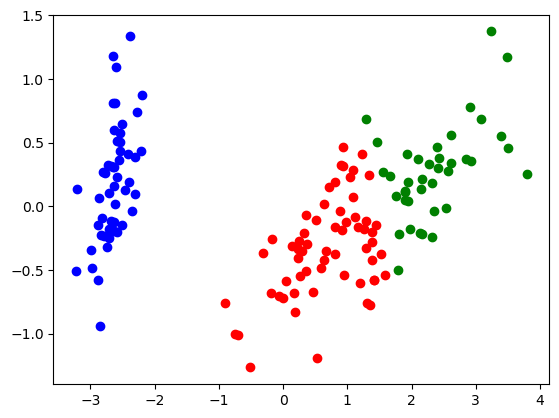

In [56]:
plt.scatter(x=iris_df.loc[iris_df['cluster']==0, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==0, 'pca_y'], marker='o', color='red')

plt.scatter(x=iris_df.loc[iris_df['cluster']==1, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==1, 'pca_y'], marker='o', color='blue')

plt.scatter(x=iris_df.loc[iris_df['cluster']==2, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==2, 'pca_y'], marker='o', color='green')

plt.show()

In [57]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

## StandardScaler로 스케일링
## PCA 2개로 축소
## 시각화

In [58]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
scaler1.fit(iris_df)
iris_scaled = scaler1.transform(iris_df)

In [59]:
# PCA 2개로 축소
pca_scaled = PCA(n_components=2)
pca_transformed_scaled = pca_scaled.fit_transform(iris_scaled)
pca_transformed_scaled.shape

(150, 2)

In [60]:
iris_df['pca_x'] = pca_transformed_scaled[:, 0]
iris_df['pca_y'] = pca_transformed_scaled[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-3.176320,0.877704
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.955944,-0.442521
2,4.7,3.2,1.3,0.2,0,1,0.828797,-3.220034,-0.219529
3,4.6,3.1,1.5,0.2,0,1,0.804352,-3.093245,-0.602616
4,5.0,3.6,1.4,0.2,0,1,0.848918,-3.270698,0.972057


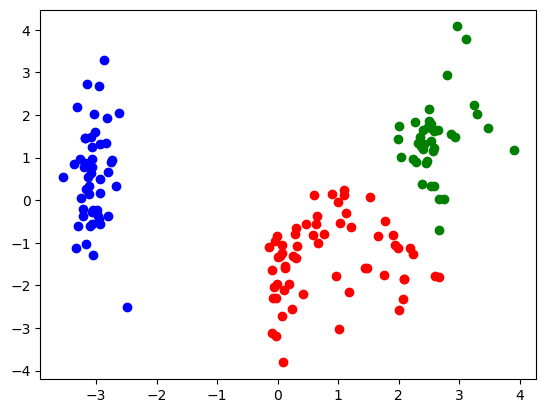

In [61]:
# 시각화
plt.scatter(x=iris_df.loc[iris_df['cluster']==0, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==0, 'pca_y'], marker='o', color='red')

plt.scatter(x=iris_df.loc[iris_df['cluster']==1, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==1, 'pca_y'], marker='o', color='blue')

plt.scatter(x=iris_df.loc[iris_df['cluster']==2, 'pca_x'],
            y=iris_df.loc[iris_df['cluster']==2, 'pca_y'], marker='o', color='green')

plt.show()

In [63]:
pca_scaled.explained_variance_ratio_

array([0.60577141, 0.26019817])

# 클러스터링 실습

In [98]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer.data.shape

(569, 30)

In [99]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [100]:
KM = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
KM.fit(cancer_df)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [101]:
KM.labels_

array([2, 1, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 1, 0, 0, 0,
       0, 1, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 0, 2, 0, 2, 0, 2,
       2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 0, 2, 1, 0, 1, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0,
       0, 2, 0, 0, 1, 1, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       2, 0, 0, 2, 1, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 1, 2, 0, 2, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0,
       2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [104]:
cancer_df['target'] = cancer.target   # 실제값
cancer_df['cluster'] = KM.labels_
cancer_df.groupby(['target', 'cluster'])['mean radius'].count()

target  cluster
0       0           63
        1           32
        2          117
1       0          354
        2            3
Name: mean radius, dtype: int64

In [105]:
# PCA 2개의 주성분
pca_cancer = PCA(n_components=2)
pca_transformed_cancer = pca_cancer.fit_transform(cancer.data)
pca_transformed_cancer.shape

(569, 2)

In [106]:
cancer_df['pca_x'] = pca_transformed_cancer[:, 0]
cancer_df['pca_y'] = pca_transformed_cancer[:, 1]
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,cluster,pca_x,pca_y
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,2,1160.142574,-293.917544
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1,1269.122443,15.630182
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,2,995.793889,39.156743
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,0,-407.180803,-67.380320
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,2,930.341180,189.340742


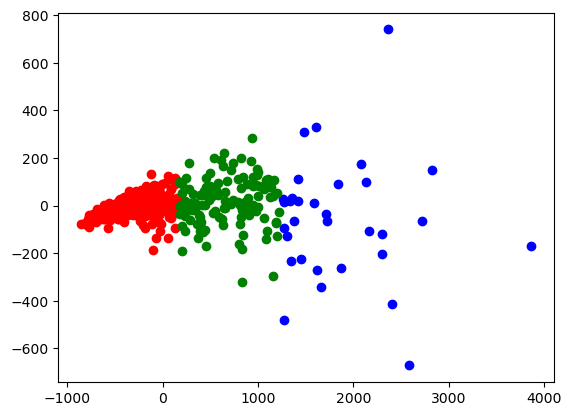

In [107]:
# 시각화
plt.scatter(x=cancer_df.loc[cancer_df['cluster']==0, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==0, 'pca_y'], marker='o', color='red')

plt.scatter(x=cancer_df.loc[cancer_df['cluster']==1, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==1, 'pca_y'], marker='o', color='blue')

plt.scatter(x=cancer_df.loc[cancer_df['cluster']==2, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==2, 'pca_y'], marker='o', color='green')

plt.show()

## StandardScaler로 스케일링
## PCA 2개로 축소
## 시각화

In [108]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
scaler2.fit(cancer_df)
cancer_scaled = scaler2.transform(cancer_df)

In [109]:
# PCA 2개로 축소
cancer_pca_scaled = PCA(n_components=2)
cancer_pca_transformed_scaled = cancer_pca_scaled.fit_transform(cancer_scaled)
cancer_pca_transformed_scaled.shape

(569, 2)

In [110]:
cancer_df['pca_x'] = cancer_pca_transformed_scaled[:, 0]
cancer_df['pca_y'] = cancer_pca_transformed_scaled[:, 1]
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,cluster,pca_x,pca_y
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,2,9.450585,2.735806
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1,3.254701,-3.816413
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,2,6.354314,-0.849379
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,0,6.127781,11.030439
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,2,4.694583,-2.037571


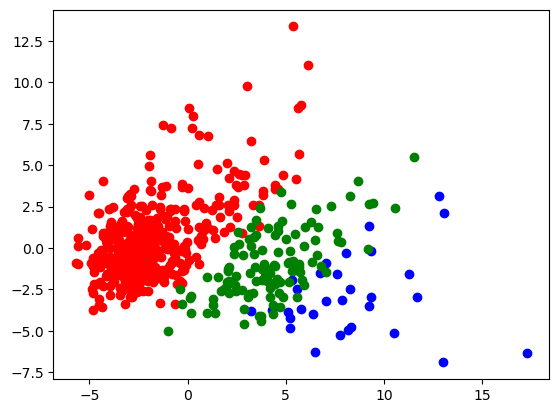

In [111]:
# 시각화
plt.scatter(x=cancer_df.loc[cancer_df['cluster']==0, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==0, 'pca_y'], marker='o', color='red')

plt.scatter(x=cancer_df.loc[cancer_df['cluster']==1, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==1, 'pca_y'], marker='o', color='blue')

plt.scatter(x=cancer_df.loc[cancer_df['cluster']==2, 'pca_x'],
            y=cancer_df.loc[cancer_df['cluster']==2, 'pca_y'], marker='o', color='green')

plt.show()

In [124]:
pca_cancer.explained_variance_ratio_   # 스케일링 전

array([0.98204467, 0.01617649])

In [125]:
cancer_pca_scaled.explained_variance_ratio_   # 스케일링 후

array([0.44432267, 0.17873169])

## PCA 2개의 주성분 , ... 그 이상 주성분 추출
## explaind_variance_ratio_이 가장 높은 주성분의 갯수
## kmeans data = pca1, pca2, cluster=2

In [126]:
# 주성분 갯수 5
import numpy as np
pca_5 = PCA(n_components=5)
pca_5.fit(cancer_scaled)
print(np.round(pca_5.explained_variance_ratio_, 3))
print(np.round(np.cumsum(pca_5.explained_variance_ratio_), 3))

[0.444 0.179 0.087 0.06  0.05 ]
[0.444 0.623 0.71  0.77  0.82 ]


In [127]:
# 주성분 갯수 7
pca_7 = PCA(n_components=7)
pca_7.fit(cancer_scaled)
print(np.round(pca_7.explained_variance_ratio_, 3))
print(np.round(np.cumsum(pca_7.explained_variance_ratio_), 3))

[0.444 0.179 0.087 0.06  0.05  0.037 0.031]
[0.444 0.623 0.71  0.77  0.82  0.857 0.888]


In [141]:
# 주성분 갯수 15
pca_15 = PCA(n_components=15)
pca_15.fit(cancer_scaled)
print(np.round(pca_15.explained_variance_ratio_, 3))
print(np.round(np.cumsum(pca_15.explained_variance_ratio_), 3))

[0.444 0.179 0.087 0.06  0.05  0.037 0.031 0.018 0.015 0.013 0.01  0.01
 0.009 0.008 0.006]
[0.444 0.623 0.71  0.77  0.82  0.857 0.888 0.906 0.921 0.934 0.945 0.955
 0.964 0.971 0.978]


In [146]:
# 주성분 갯수 25
pca_25 = PCA(n_components=25)
pca_25.fit(cancer_scaled)
print(np.round(pca_25.explained_variance_ratio_, 3))
print(np.round(np.cumsum(pca_25.explained_variance_ratio_), 3))

[0.444 0.179 0.087 0.06  0.05  0.037 0.031 0.018 0.015 0.013 0.01  0.01
 0.009 0.008 0.006 0.005 0.004 0.002 0.002 0.002 0.001 0.001 0.001 0.001
 0.001]
[0.444 0.623 0.71  0.77  0.82  0.857 0.888 0.906 0.921 0.934 0.945 0.955
 0.964 0.971 0.978 0.983 0.987 0.99  0.992 0.994 0.995 0.996 0.997 0.998
 0.998]


In [133]:
# 7개 주성분으로 kmeans 클러스터링
# 데이터 변환(PCA 적용)
X_pca_7 = pca_7.transform(cancer_scaled)
X_pca_7.shape

(569, 7)

In [134]:
df_7 = pd.DataFrame(X_pca_7, columns=['ftr1', 'ftr2',
                                      'ftr3', 'ftr4',
                                      'ftr5', 'ftr6',
                                      'ftr7'])
df_7[:3]

,ftr1,ftr2,ftr3,ftr4,ftr5,ftr6,ftr7
0,9.450585,2.735806,-1.558327,-2.895530,-2.539727,-0.287141,3.835782
1,3.254701,-3.816413,-0.461924,-1.187119,0.370073,-0.185907,0.286871
2,6.354314,-0.849379,-0.338577,-1.017415,-0.137864,0.780172,-0.431297


In [136]:
kmeans_7 = KMeans(n_clusters=2, random_state=42)
kmeans_7_labels = kmeans_7.fit_predict(X_pca_7)

df_7['kmeans_label'] = kmeans_7_labels

print("KMeans Silhouette Score:", silhouette_score(X_pca_7, kmeans_7_labels))

KMeans Silhouette Score: 0.3982136430468014


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [143]:
# 15개 주성분으로 kmeans 클러스터링
# 데이터 변환(PCA 적용)
X_pca_15 = pca_15.transform(cancer_scaled)
X_pca_15.shape

(569, 15)

In [144]:
df_15 = pd.DataFrame(X_pca_15, columns=['ftr1', 'ftr2',
                                      'ftr3', 'ftr4',
                                      'ftr5', 'ftr6',
                                      'ftr7', 'ftr8', 'ftr9', 'ftr10', 'ftr11',
                                      'ftr12', 'ftr13', 'ftr14', 'ftr15'])

In [145]:
kmeans_15 = KMeans(n_clusters=2, random_state=42)
kmeans_15_labels = kmeans_15.fit_predict(X_pca_15)

df_15['kmeans_label'] = kmeans_15_labels

print("KMeans Silhouette Score:", silhouette_score(X_pca_15, kmeans_15_labels))

KMeans Silhouette Score: 0.374108224686461


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [147]:
# 25개 주성분으로 kmeans 클러스터링
# 데이터 변환(PCA 적용)
X_pca_25 = pca_25.transform(cancer_scaled)
X_pca_25.shape

(569, 25)

In [149]:
df_25 = pd.DataFrame(X_pca_25, columns=['ftr1', 'ftr2',
                                      'ftr3', 'ftr4',
                                      'ftr5', 'ftr6',
                                      'ftr7', 'ftr8', 'ftr9', 'ftr10', 'ftr11',
                                      'ftr12', 'ftr13', 'ftr14', 'ftr15', 'ftr16',
                                      'ftr17', 'ftr18', 'ftr19', 'ftr20', 'ftr21',
                                      'ftr22', 'ftr23', 'ftr24', 'ftr25'])

In [151]:
kmeans_25 = KMeans(n_clusters=2, random_state=42)
kmeans_25_labels = kmeans_25.fit_predict(X_pca_25)

df_25['kmeans_label'] = kmeans_25_labels

print("KMeans Silhouette Score:", silhouette_score(X_pca_25, kmeans_25_labels))

KMeans Silhouette Score: 0.36773637741249793


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
